In [1]:
import xgboost as xgb
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

/home/theo/miniconda3/envs/energy/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load Data

In [ ]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

import pandas as pd
import numpy as np
import xgboost as xgb
from helper import *
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------------------------------------
# 1. Load data
# ---------------------------------------------------------
set_seed(42)
merged_building_df = pd.read_csv('/home/theo/Desktop/CESI_DUTh/XAI_Energy_Consumption_Prediction/Data/merged_nord_with_power.csv')

metric_datasets = extract_metric_datasets(merged_building_df)
co2_df = metric_datasets.get('CO2 indoor')
humidity_df = metric_datasets.get('HUM indoor')
temp_df = metric_datasets.get('TMP indoor')       
voct_df = metric_datasets.get('VOCT indoor')
dbaa_df = metric_datasets.get('DBAA indoor')
light_lux_df = metric_datasets.get('LIGHT_LUX indoor')
occupancy_rate_df = metric_datasets.get('OCCUPANCY_RATE indoor') 

df = merged_building_df

🔑 All random seeds set to: 42


In [3]:
df.head()

,Date and Time,Consommation,espacesalaries_s41,b20,t21,t23_salletp,b10,t24_fablab,S35,t09,...,t11,B16,t17,t14,b24,t15,b18,b11,b23,t12
0,2026-03-01 00:00:00,3.250000,461.0,339.0,242.0,855.0,375.0,130.0,0.0,678.0,...,337.0,333.0,NaN,0.0,431.0,261.0,359.0,294.0,336.0,521.0
1,2026-03-01 00:10:00,3.166667,452.0,328.0,244.0,853.0,368.0,130.0,0.0,668.0,...,334.0,333.0,NaN,0.0,431.0,282.0,352.0,291.0,329.0,529.0
2,2026-03-01 00:20:00,2.250000,442.0,331.0,238.0,877.0,369.0,136.0,0.0,688.0,...,334.0,323.0,NaN,0.0,434.0,262.0,361.0,286.0,335.0,518.0
3,2026-03-01 00:30:00,1.333333,446.0,327.0,237.0,875.0,367.0,138.0,0.0,690.0,...,331.0,340.0,NaN,0.0,426.0,270.0,352.0,289.0,321.0,519.0
4,2026-03-01 00:40:00,1.916667,453.0,NaN,243.0,864.0,358.0,134.0,0.0,682.0,...,NaN,331.0,NaN,0.0,426.0,261.0,352.0,297.0,325.0,507.0


In [4]:
columns = list(df.columns)

# Build flattened train/val/test arrays

In [5]:
# ---------------------------------------------------------
# 2. Clean & scale
# ---------------------------------------------------------
cols_to_drop = ['Date and Time', 'Horodatage_Début', 'Horodatage_Fin', 'Valeur']
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

df_numeric = df.drop(columns=cols_to_drop)
df_numeric = df_numeric.ffill().bfill()

target_col_name = 'Consommation'
assert target_col_name in df_numeric.columns, f"'{target_col_name}' not found in dataframe columns!"
target_idx = df_numeric.columns.get_loc(target_col_name)

scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_numeric.values)
print(f"Transformed sequence shape: {data_scaled.shape}")

def inverse_transform_target(values_scaled, scaler, col_idx):
    mean = scaler.mean_[col_idx]
    scale = scaler.scale_[col_idx]
    return values_scaled * scale + mean

Transformed sequence shape: (9648, 27)


In [6]:

# ---------------------------------------------------------
# 3. Build sliding windows: keep ONLY Consommation_t-0,
#    drop all other target lags.
# ---------------------------------------------------------
seq_length = 12
gap = seq_length

n_windows = len(data_scaled) - seq_length
split_point = int(n_windows * 0.8)

train_range = range(0, split_point - gap)
test_range = range(split_point, n_windows)

def build_window_row(i):
    window = data_scaled[i : i + seq_length, :]
    non_target = np.delete(window, target_idx, axis=1)
    consumption_t0 = window[-1, target_idx]
    return np.concatenate([non_target.flatten(), [consumption_t0]])

X_train, y_train = [], []
for i in train_range:
    X_train.append(build_window_row(i))
    y_train.append(data_scaled[i + seq_length, target_idx])

X_test, y_test = [], []
for i in test_range:
    X_test.append(build_window_row(i))
    y_test.append(data_scaled[i + seq_length, target_idx])

X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

base_feature_names = [c for c in df_numeric.columns.tolist() if c != target_col_name]
flat_feature_names = [
    f"{feat}_t-{seq_length-1-t}"
    for t in range(seq_length)
    for feat in base_feature_names
] + ["Consommation_t-0"]

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"len(flat_feature_names): {len(flat_feature_names)}")

X_train: (7696, 313), X_test: (1928, 313)
len(flat_feature_names): 313


In [7]:
# ---------------------------------------------------------
# 5. Train XGBoost
# ---------------------------------------------------------
model = xgb.XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

# # ---------------------------------------------------------
# # 5. Train Gradient Boosting Regressor
# # ---------------------------------------------------------
# from sklearn.ensemble import GradientBoostingRegressor
# model = GradientBoostingRegressor(
#     n_estimators=500,
#     max_depth=6,
#     learning_rate=0.05,
#     random_state=42,
# )
# model.fit(X_train, y_train)


# # ---------------------------------------------------------
# # 5. Train LightGBM Regressor
# # ---------------------------------------------------------

# import lightgbm as lgb

# model = lgb.LGBMRegressor(
#     n_estimators=500,
#     max_depth=7,
#     learning_rate=0.05,
#     random_state=42,
#     verbose=-1,   # suppress LightGBM's default per-iteration logging
# )
# model.fit(X_train, y_train)


# # # ---------------------------------------------------------
# # # 5. Train Linear Regression
# # # ---------------------------------------------------------
# # from sklearn.linear_model import LinearRegression

# # model = LinearRegression()
# # model.fit(X_train, y_train) 

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [8]:

# ---------------------------------------------------------
# 6. Predict & evaluate (original units)
# ---------------------------------------------------------
y_pred = model.predict(X_test)

y_pred_orig = inverse_transform_target(y_pred, scaler, target_idx)
y_test_orig = inverse_transform_target(y_test, scaler, target_idx)

mae = mean_absolute_error(y_test_orig, y_pred_orig)
mse = mean_squared_error(y_test_orig, y_pred_orig)
rmse = np.sqrt(mse)
value_range = y_test_orig.max() - y_test_orig.min()
nrmse = rmse / value_range if value_range != 0 else float('nan')
r2 = r2_score(y_test_orig, y_pred_orig)

print(f"MAE   : {mae:.4f}")
print(f"MSE   : {mse:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"NRMSE : {nrmse:.4f}")
print(f"R2    : {r2:.4f}")

MAE   : 0.4721
MSE   : 0.3219
RMSE  : 0.5673
NRMSE : 0.0920
R2    : 0.8494


In [9]:
import numpy as np
import shap

# 1. Compute standard SHAP values with TreeExplainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)  # Shape: (num_samples, 2641)

# 2. Separate the base features from any trailing targets (e.g., Consommation_t-0)
num_base_features = len(base_feature_names)  # e.g., 220
seq_len = 12

# Reshape the feature SHAP matrix to (num_samples, num_base_features, seq_len)
# and aggregate across the time axis (axis 2)
shap_features_only = shap_values[:, : num_base_features * seq_len]
shap_collapsed = shap_features_only.reshape(
    -1, num_base_features, seq_len
).sum(axis=2)

# Collapse feature values similarly for beeswarm color scaling
X_test_collapsed = (
    X_test[:, : num_base_features * seq_len]
    .reshape(-1, num_base_features, seq_len)
    .mean(axis=2)
)

# 3. Plot without time-step suffixes
shap.summary_plot(
    shap_collapsed,
    features=X_test_collapsed,
    feature_names=base_feature_names,
    max_display=20,
    show=False
)

plt.savefig("shap_bar_grouped_no_t.pdf", format="pdf", bbox_inches="tight")
plt.show()
plt.close()

/tmp/ipykernel_123179/1835022864.py:27: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


<Figure size 800x950 with 2 Axes>

In [10]:
plt.savefig("shap_bar_grouped_no_t.pdf", format="pdf", bbox_inches="tight")
plt.show()
plt.close()

<Figure size 640x480 with 0 Axes>

/tmp/ipykernel_123179/3690717103.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


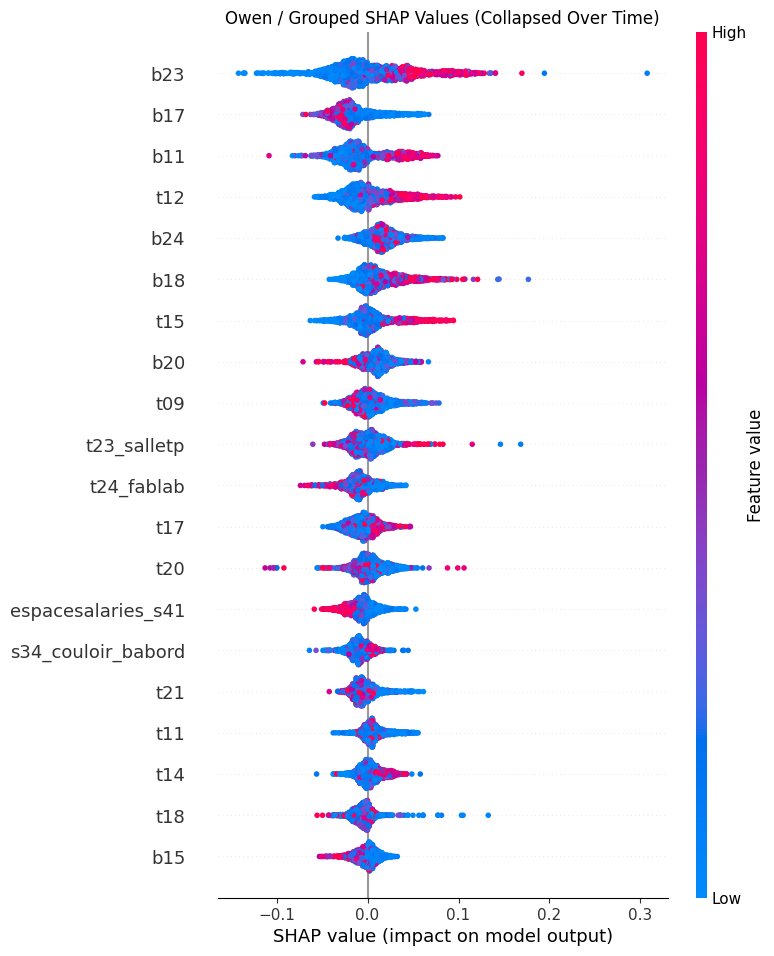

/tmp/ipykernel_123179/3690717103.py:17: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


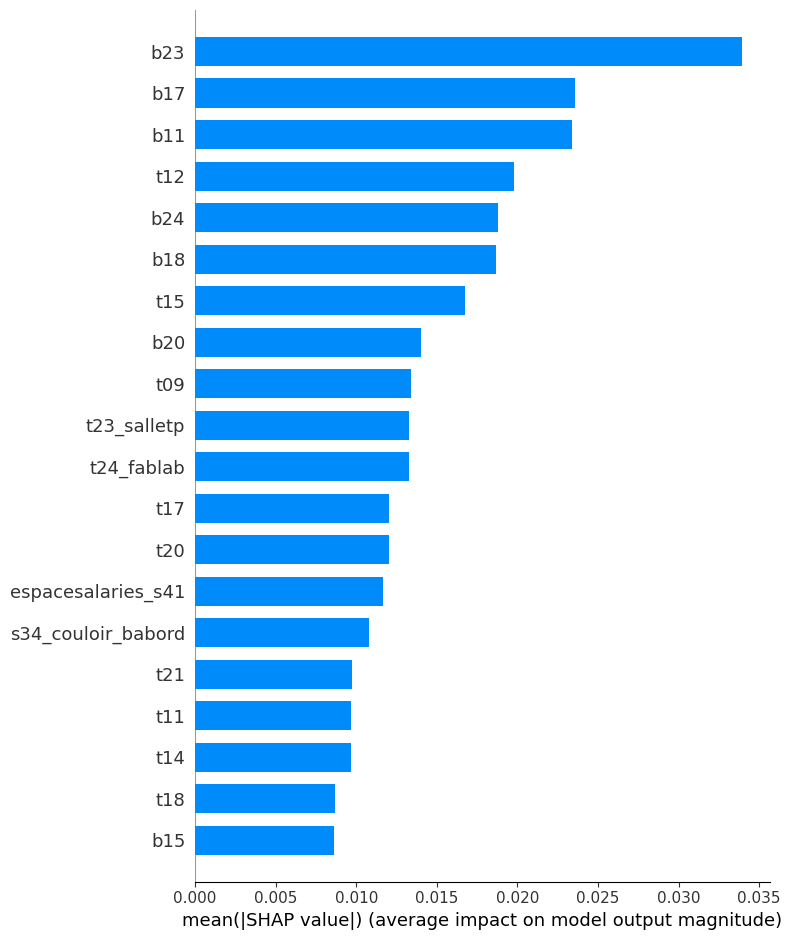

In [12]:
import matplotlib.pyplot as plt

# Beeswarm Summary Plot
shap.summary_plot(
    shap_collapsed,
    features=X_test_collapsed,
    feature_names=base_feature_names,
    max_display=20,
    show=False
)
plt.title("Owen / Grouped SHAP Values (Collapsed Over Time)", fontsize=12)
plt.savefig("shap_summary_grouped_no_t.pdf", format="pdf", bbox_inches="tight")
plt.show()
plt.close()

# Bar Summary Plot
shap.summary_plot(
    np.abs(shap_collapsed),
    features=X_test_collapsed,
    plot_type="bar",
    feature_names=base_feature_names,
    max_display=20,
    show=False
)
plt.savefig("shap_bar_grouped_no_t.pdf", format="pdf", bbox_inches="tight")
plt.show()
plt.close()

In [ ]:
# ---------------------------------------------------------
# 7. SHAP Feature Importance
# ---------------------------------------------------------
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print(f"shap_values shape: {shap_values.shape}")   # sanity check -> should match (n_test, len(flat_feature_names))

mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_df = (
    pd.DataFrame({"feature": flat_feature_names, "mean_abs_shap": mean_abs_shap})
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
print(importance_df.head(20).to_string(index=False))

shap.summary_plot(shap_values, features=X_test, feature_names=flat_feature_names, max_display=20, show=True)
shap.summary_plot(shap_values, features=X_test, feature_names=flat_feature_names, plot_type="bar", max_display=20, show=True)

shap_values shape: (1928, 2641)
                            feature  mean_abs_shap
                   Consommation_t-0       0.582749
DBAP indoor b21_sallecreativite_t-0       0.021575
                DBAA indoor t15_t-0       0.020809
  TMP indoor espacesalaries_s40_t-0       0.019171
                DBAA indoor S35_t-1       0.011866
                DBAP indoor t12_t-0       0.009974
                 TMP indoor t15_t-0       0.009446
  TMP indoor espacesalaries_s41_t-0       0.009331
           LIGHT_LUX indoor S35_t-1       0.007046
                VOCT indoor t15_t-0       0.006544
  TMP indoor espacesalaries_s40_t-2       0.006301
                 TMP indoor t09_t-1       0.005923
                DBAP indoor t15_t-5       0.005590
                DBAP indoor t09_t-0       0.005563
CO2 indoor b21_sallecreativite_t-10       0.005533
           LIGHT_LUX indoor S35_t-0       0.005384
                 TMP indoor b24_t-0       0.005139
                 TMP indoor t15_t-6       0.005068

/tmp/ipykernel_34162/2835886046.py:17: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, features=X_test, feature_names=flat_feature_names, max_display=20, show=True)


<Figure size 800x950 with 2 Axes>

/tmp/ipykernel_34162/2835886046.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, features=X_test, feature_names=flat_feature_names, plot_type="bar", max_display=20, show=True)


<Figure size 800x950 with 1 Axes>

/tmp/ipykernel_34162/2471589862.py:17: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


Dropped 1 Consommation column(s), 2640 features remain


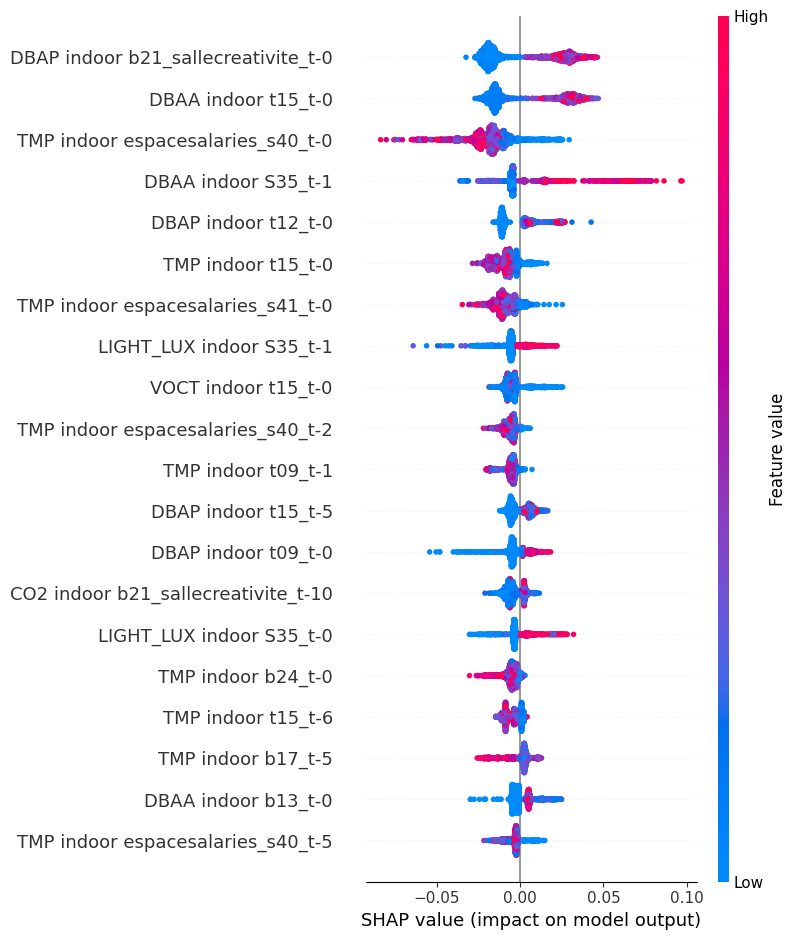

/tmp/ipykernel_34162/2471589862.py:29: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


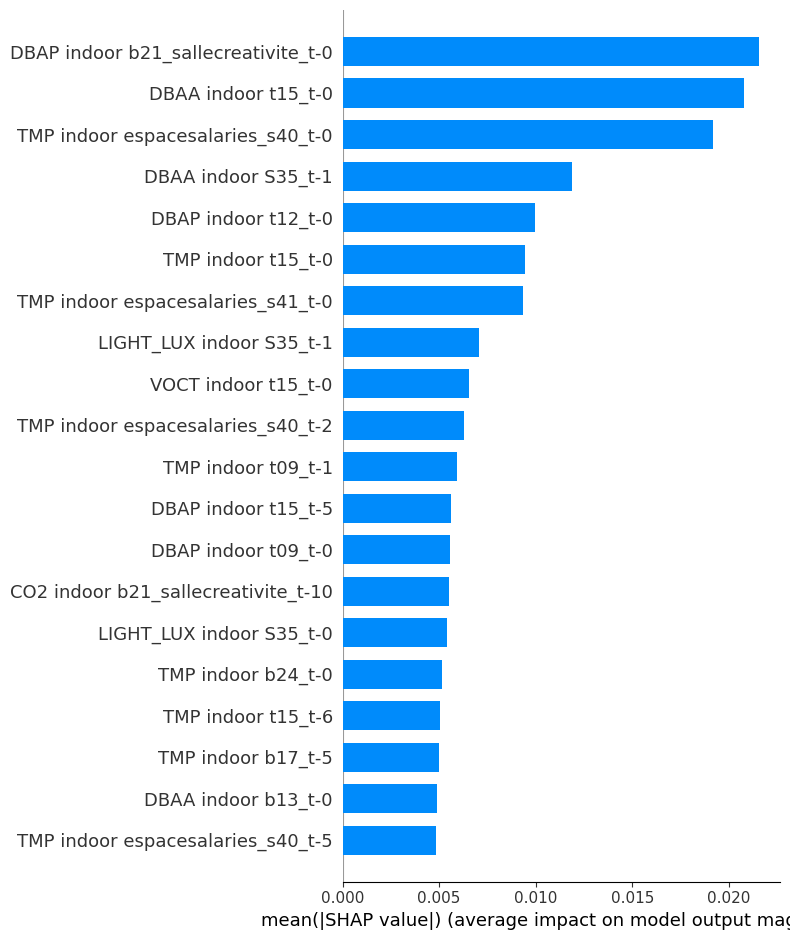

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Find every column whose name contains "Consommation" (matches both
# "Consommation_t-*" history lags and the "Consommation_t-0" column)
exclude_mask = np.array([
    "Consommation" not in name for name in flat_feature_names
])

shap_values_filtered = shap_values[:, exclude_mask]
X_test_filtered = X_test[:, exclude_mask]
feature_names_filtered = [n for n, keep in zip(flat_feature_names, exclude_mask) if keep]

print(f"Dropped {(~exclude_mask).sum()} Consommation column(s), {exclude_mask.sum()} features remain")

# Beeswarm, without Consommation
shap.summary_plot(
    shap_values_filtered,
    features=X_test_filtered,
    feature_names=feature_names_filtered,
    max_display=20,
    show=False,
)
plt.savefig("shap_summary_no_consommation.pdf", format="pdf", bbox_inches="tight")
plt.show()
plt.close()

# Bar chart, without Consommation
shap.summary_plot(
    shap_values_filtered,
    features=X_test_filtered,
    plot_type="bar",
    feature_names=feature_names_filtered,
    max_display=20,
    show=False,
)
plt.savefig("shap_bar_no_consommation.pdf", format="pdf", bbox_inches="tight")
plt.show()
plt.close()

/tmp/ipykernel_34162/3343243750.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, features=X_test, feature_names=flat_feature_names, max_display=20, show=False)


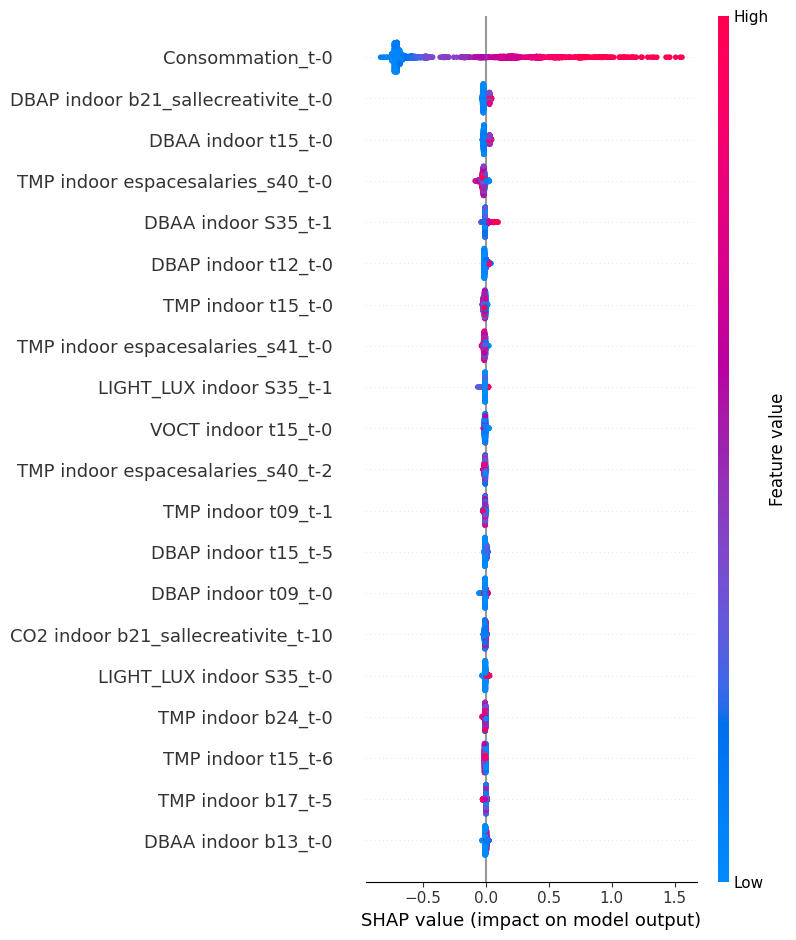

In [ ]:
import matplotlib.pyplot as plt

shap.summary_plot(shap_values, features=X_test, feature_names=flat_feature_names, max_display=20, show=False)
plt.savefig("shap_summary_plot.pdf", format="pdf", bbox_inches="tight")
plt.show()   # optional: still display it inline in the notebook
plt.close()  # free the figure
